# Chess Elo Prediction — Preprocessing Deep Dive

This notebook documents every preprocessing decision made during development,
compares alternative approaches with benchmarks, and shows the memory management
techniques needed to work with millions of chess games.

**Contents**
1. Data Loading and Memory Management
2. Filtering Pipeline
3. Elo Distribution and Class Imbalance
4. Target Representation — Hard Labels vs. Soft Distributions
5. Feature Engineering — Board Features
6. Feature Engineering — Clock Features
7. Move Sequence Representation
8. Sampling Strategy
9. Scaling and Normalisation
10. Train / Val / Test Split
11. Development History
12. Summary

*Dataset: Lichess standard-rated games, May 2017 (~3 M games, 5.9 GB compressed).*

In [5]:
import sys, re, io, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import zstandard as zstd
from pathlib import Path
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

sys.path.insert(0, '.')
DATA_PATH  = '../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst'
CACHE_DIR  = Path('cache_preproc')
CACHE_DIR.mkdir(exist_ok=True)

SAMPLE_SIZE = 1_000_000
SEED        = 42
np.random.seed(SEED)

print(f'Python  {sys.version.split()[0]}')
print(f'Pandas  {pd.__version__}')
print(f'Sample  {SAMPLE_SIZE:,} games')

Python  3.13.7
Pandas  3.0.3
Sample  1,000,000 games


## 1 · Data Loading and Memory Management

Lichess distributes game data as `.pgn.zst` files (PGN compressed with Zstandard).
The May 2017 file contains ~3 million games and is 5.9 GB on disk.

### PGN format

Each game is a block of header tags followed by the move text:

```
[Event "Rated Blitz game"]
[WhiteElo "1532"]   [BlackElo "1489"]
[TimeControl "180+0"]

1. e4 { [%clk 0:02:59] } 1... e5 { [%clk 0:02:58] } 2. Nf3 ...
```

Headers give metadata (ratings, time control, result). The move text contains
optional clock annotations `[%clk HH:MM:SS]` and engine evaluations `[%eval ±X.XX]`.

### The memory challenge

Loading the full file naively triggers `ArrowMemoryError: realloc of size 9932111872 failed`.
PyArrow cannot allocate a ~10 GB contiguous buffer in a single call.

**Solution**: stream-parse using `zstandard.stream_reader`, collecting one Python `dict`
per game. `pd.DataFrame(list_of_dicts)` uses the `nested_data_to_arrays` code path,
which allocates column-by-column in small chunks — avoiding the single contiguous
allocation. Switching to `pd.DataFrame(dict_of_lists)` (the `dict_to_mgr` path)
actually makes memory usage *worse*.

In [6]:
def load_pgn_zst(path, max_games):
    records = []
    with open(path, 'rb') as fh:
        dctx   = zstd.ZstdDecompressor()
        stream = io.TextIOWrapper(dctx.stream_reader(fh), encoding='utf-8', errors='replace')
        headers, moves_lines, in_moves = {}, [], False
        for line in stream:
            line = line.strip()
            if line.startswith('['):
                in_moves = False
                m = re.match(r'\[(\w+)\s+"(.*)"\]', line)
                if m: headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers, moves_lines = {}, []
                    if len(records) >= max_games: break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers: moves_lines.append(line)
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)
    return pd.DataFrame(records)

In [7]:
proc       = psutil.Process()
mem_before = proc.memory_info().rss / 1e6

cache_raw = CACHE_DIR / f'raw_{SAMPLE_SIZE}.pkl'
if cache_raw.exists():
    df_raw  = pickle.loads(cache_raw.read_bytes())
    print(f'Loaded from cache: {len(df_raw):,} games')
else:
    t0      = time.time()
    df_raw  = load_pgn_zst(DATA_PATH, SAMPLE_SIZE)
    elapsed = time.time() - t0
    cache_raw.write_bytes(pickle.dumps(df_raw))
    print(f'Parsed {len(df_raw):,} games in {elapsed:.1f}s')

mem_after = proc.memory_info().rss / 1e6
print(f'Memory: {mem_before:.0f} MB -> {mem_after:.0f} MB  (+{mem_after - mem_before:.0f} MB)')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns)}')

Parsed 1,000,000 games in 49.3s
Memory: 222 MB -> 53 MB  (+-169 MB)
Columns (18): ['Event', 'Site', 'White', 'Black', 'Result', 'UTCDate', 'UTCTime', 'WhiteElo', 'BlackElo', 'WhiteRatingDiff', 'BlackRatingDiff', 'ECO', 'Opening', 'TimeControl', 'Termination', 'Moves', 'WhiteTitle', 'BlackTitle']


In [8]:
print(f'Shape: {df_raw.shape}')
print()
print('Top 12 TimeControl values:')
print(df_raw['TimeControl'].value_counts().head(12).to_string())
print()
print('Results:')
print(df_raw['Result'].value_counts().to_string())
if 'Termination' in df_raw.columns:
    print()
    print('Terminations (top 6):')
    print(df_raw['Termination'].value_counts().head(6).to_string())

Shape: (1000000, 18)

Top 12 TimeControl values:
TimeControl
300+0    192208
180+0    172201
60+0     158334
600+0    138198
180+2     37926
120+1     27691
300+3     27106
30+0      26899
15+0      20107
120+0     19233
900+0     14180
300+5      9910

Results:
Result
1-0        496176
0-1        464722
1/2-1/2     38873
*             229

Terminations (top 6):
Termination
Normal              663184
Time forfeit        331654
Abandoned             4911
Unterminated           174
Rules infraction        77


## 2 · Filtering Pipeline

Raw PGN data contains noise that would corrupt training: games with missing ratings,
bullet games played on reaction rather than skill, and games that ended abnormally.
Each filter stage is justified below and its effect on dataset size is measured.

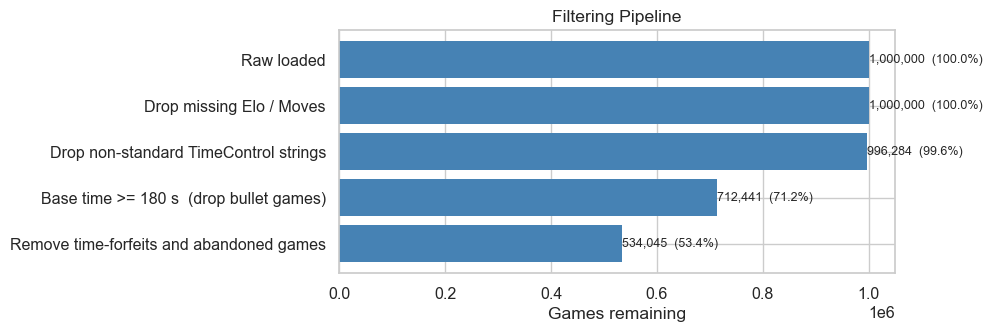

Retained: 534,045 / 1,000,000 games (53.4%)


In [9]:
stages = [('Raw loaded', len(df_raw))]
df = df_raw.copy()

# 1. Parse Elos — drop games where either rating is missing or non-numeric
for col in ['WhiteElo', 'BlackElo']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df[['WhiteElo', 'BlackElo']] = df[['WhiteElo', 'BlackElo']].astype(int)
stages.append(('Drop missing Elo / Moves', len(df)))

# 2. Parse TimeControl string (format: 'base+increment')
TC_RE = re.compile(r'^(\d+)\+(\d+)$')
def parse_tc(s):
    m = TC_RE.match(str(s))
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)

df[['tc_base', 'tc_inc']] = df['TimeControl'].apply(lambda x: pd.Series(parse_tc(x)))
df.dropna(subset=['tc_base'], inplace=True)
df['tc_base'] = df['tc_base'].astype(int)
df['tc_inc']  = df['tc_inc'].astype(int)
stages.append(('Drop non-standard TimeControl strings', len(df)))

# 3. Keep only games with base time >= 3 minutes (drop bullet / ultrabullet)
df = df[df['tc_base'] >= 180]
stages.append(('Base time >= 180 s  (drop bullet games)', len(df)))

# 4. Remove games that ended due to time forfeit, abandonment, or technical issues
if 'Termination' in df.columns:
    bad = {'Time forfeit', 'Abandoned', 'Unterminated'}
    df  = df[~df['Termination'].isin(bad)]
stages.append(('Remove time-forfeits and abandoned games', len(df)))

df = df.reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 3.5))
labels  = [s[0] for s in stages]
counts  = [s[1] for s in stages]
bars    = ax.barh(labels, counts, color='steelblue', edgecolor='none')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}  ({cnt / counts[0] * 100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Games remaining')
ax.set_title('Filtering Pipeline')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Retained: {len(df):,} / {len(df_raw):,} games ({len(df)/len(df_raw)*100:.1f}%)')

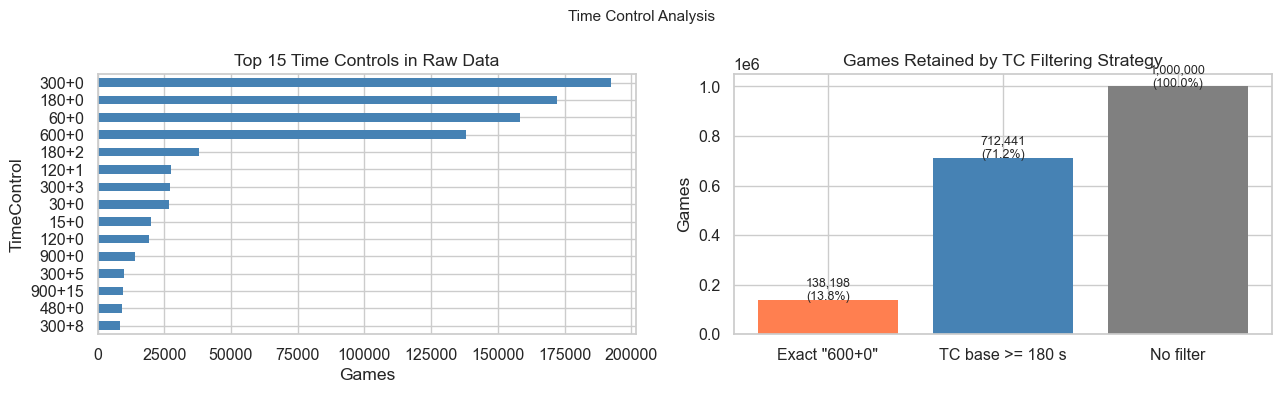

v1 of this project used exact "600+0" matching.
That kept only 138,198 games (13.8%) -> MAE ~1630 (model predicts mean for everything).

TC_BASE_MIN=180 keeps all 3-min+ games regardless of increment,
giving 8-10x more training data and much better coverage of Elo ranges.


In [10]:
raw_bases   = pd.to_numeric(df_raw['TimeControl'].str.extract(r'^(\d+)\+')[0], errors='coerce')
exact_600_0 = (df_raw['TimeControl'] == '600+0').sum()
broad_180   = (raw_bases >= 180).sum()
no_filter   = len(df_raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tc_counts = df_raw['TimeControl'].value_counts().head(15)
tc_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Top 15 Time Controls in Raw Data')
axes[0].set_xlabel('Games')
axes[0].invert_yaxis()

strategies = {'Exact "600+0"': exact_600_0,
              'TC base >= 180 s': broad_180,
              'No filter': no_filter}
bars = axes[1].bar(list(strategies.keys()), list(strategies.values()),
                   color=['coral', 'steelblue', 'gray'], edgecolor='none')
for bar, val in zip(bars, strategies.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f'{val:,}\n({val/no_filter*100:.1f}%)', ha='center', fontsize=9)
axes[1].set_title('Games Retained by TC Filtering Strategy')
axes[1].set_ylabel('Games')

plt.suptitle('Time Control Analysis', fontsize=11)
plt.tight_layout()
plt.show()

print('v1 of this project used exact "600+0" matching.')
print(f'That kept only {exact_600_0:,} games ({exact_600_0/no_filter*100:.1f}%) '
      f'-> MAE ~1630 (model predicts mean for everything).')
print()
print('TC_BASE_MIN=180 keeps all 3-min+ games regardless of increment,')
print('giving 8-10x more training data and much better coverage of Elo ranges.')

## 3 · Elo Distribution and Class Imbalance

Lichess is heavily skewed toward intermediate players (1400–1800 Elo).
Without accounting for this, the model will overfit the dense centre and
systematically underperform at extreme ratings.

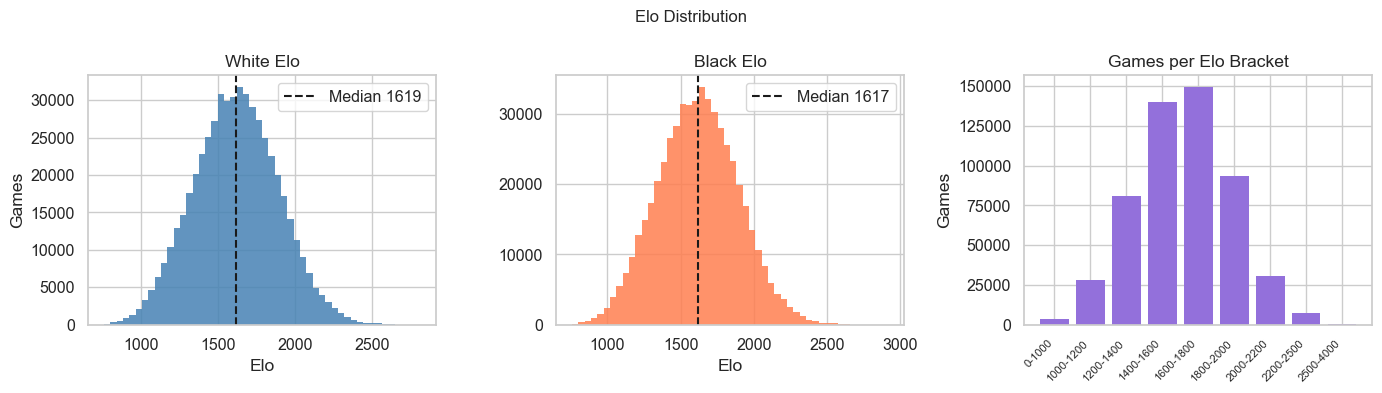

Most common : (1600, 1800] — 149,498 games
Least common: (2500, 4000] — 444 games
Imbalance ratio: 337x

This motivates WeightedRandomSampler in Section 8.


In [11]:
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]
avg_elo  = (df['WhiteElo'] + df['BlackElo']) / 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['WhiteElo'], bins=50, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(df['WhiteElo'].median(), color='k', lw=1.5, ls='--',
                label=f'Median {int(df["WhiteElo"].median())}')
axes[0].set_title('White Elo'); axes[0].set_xlabel('Elo'); axes[0].set_ylabel('Games')
axes[0].legend()

axes[1].hist(df['BlackElo'], bins=50, color='coral', edgecolor='none', alpha=0.85)
axes[1].axvline(df['BlackElo'].median(), color='k', lw=1.5, ls='--',
                label=f'Median {int(df["BlackElo"].median())}')
axes[1].set_title('Black Elo'); axes[1].set_xlabel('Elo'); axes[1].legend()

bracket_labels = [f'{ELO_BINS[i]}-{ELO_BINS[i+1]}' for i in range(len(ELO_BINS)-1)]
bracket_counts = pd.cut(avg_elo, bins=ELO_BINS).value_counts().sort_index()
axes[2].bar(range(len(bracket_counts)), bracket_counts.values,
            color='mediumpurple', edgecolor='none')
axes[2].set_xticks(range(len(bracket_labels)))
axes[2].set_xticklabels(bracket_labels, rotation=45, ha='right', fontsize=8)
axes[2].set_title('Games per Elo Bracket'); axes[2].set_ylabel('Games')

plt.suptitle('Elo Distribution', fontsize=12)
plt.tight_layout()
plt.show()

top_bracket = bracket_counts.idxmax()
bot_bracket = bracket_counts.idxmin()
print(f'Most common : {top_bracket} — {bracket_counts.max():,} games')
print(f'Least common: {bot_bracket} — {bracket_counts.min():,} games')
print(f'Imbalance ratio: {bracket_counts.max() / bracket_counts.min():.0f}x')
print()
print('This motivates WeightedRandomSampler in Section 8.')

## 4 · Target Representation — Hard Labels vs. Soft Distributions

A naive approach is to treat Elo prediction as regression (MSE on a single number)
or 40-class classification (one-hot bin). Both have problems:

- **Regression (MSE)**: penalises 1600 → 1700 the same as 1600 → 1900, ignoring
  the ordinal structure.
- **Hard classification**: 39 out of 40 bins receive zero gradient every step.

**Better approach**: predict a *probability distribution* over 40 Elo bins.
The target is a Gaussian centred on the true Elo with σ = 200. The loss is
KL divergence between the predicted and target distributions.

Why σ = 200? The Elo formula `P(win) = 1 / (1 + 10^(delta/400))` implies that
a 200-pt difference corresponds to ~76% win probability. Two players within 200 Elo
are very hard to distinguish from game statistics alone — the Gaussian spreads
the label mass over this uncertainty region.

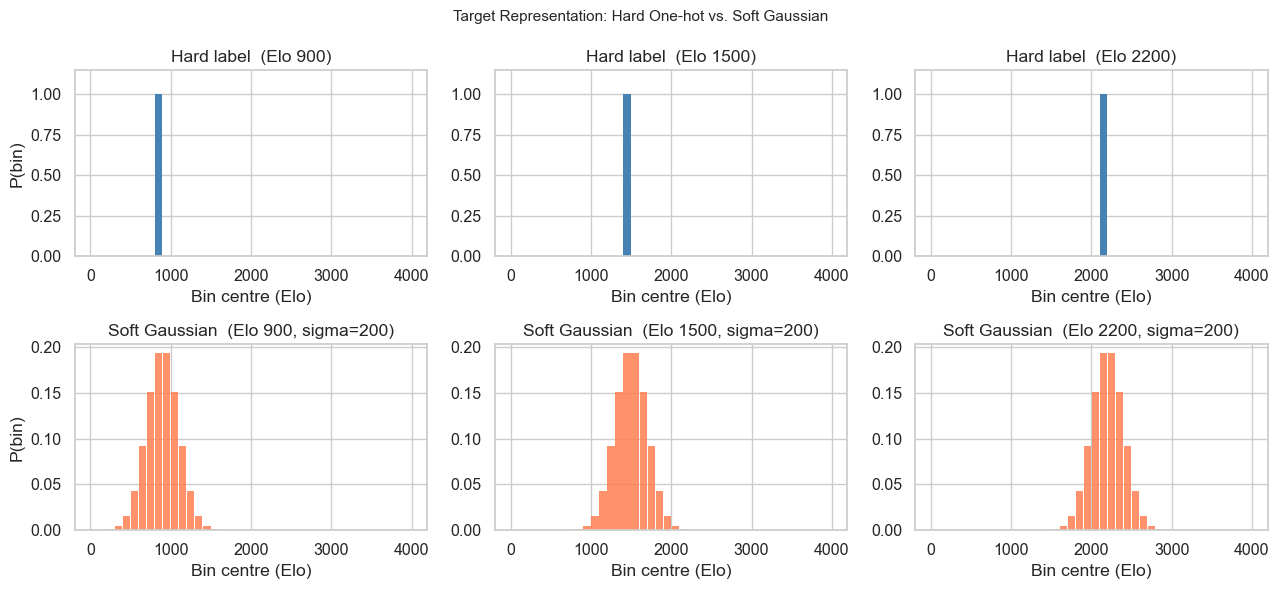

Hard: 39 of 40 bins get zero gradient each step.
Soft: every bin contributes, gradient signal is much denser.


In [12]:
N_BINS      = 40
BIN_EDGES   = np.linspace(0, 4000, N_BINS + 1)
BIN_CENTERS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

def hard_label(elo):
    idx = int(np.clip(np.searchsorted(BIN_EDGES[1:], elo), 0, N_BINS - 1))
    y   = np.zeros(N_BINS)
    y[idx] = 1.0
    return y

def soft_label(elo, sigma=200):
    probs = np.exp(-0.5 * ((BIN_CENTERS - elo) / sigma) ** 2)
    return probs / probs.sum()

example_elos = [900, 1500, 2200]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for col, elo in enumerate(example_elos):
    axes[0, col].bar(BIN_CENTERS, hard_label(elo), width=90,
                     color='steelblue', edgecolor='none')
    axes[0, col].set_title(f'Hard label  (Elo {elo})')
    axes[0, col].set_ylim(0, 1.15)
    axes[1, col].bar(BIN_CENTERS, soft_label(elo), width=90,
                     color='coral', edgecolor='none', alpha=0.85)
    axes[1, col].set_title(f'Soft Gaussian  (Elo {elo}, sigma=200)')

for row in range(2):
    axes[row, 0].set_ylabel('P(bin)')
    for col in range(3):
        axes[row, col].set_xlabel('Bin centre (Elo)')

plt.suptitle('Target Representation: Hard One-hot vs. Soft Gaussian', fontsize=11)
plt.tight_layout()
plt.show()

print('Hard: 39 of 40 bins get zero gradient each step.')
print('Soft: every bin contributes, gradient signal is much denser.')

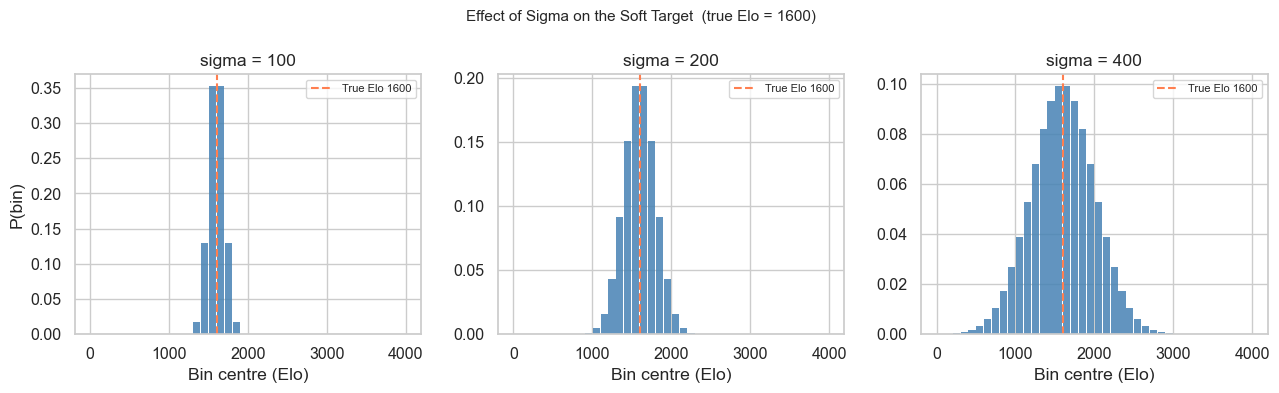

sigma=100: overconfident — forces the model to distinguish 1550 from 1650 precisely.
sigma=200: matches Elo system uncertainty; used in all models.
sigma=400: too broad — 1200 and 2000 Elo look nearly the same to the loss function.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
elo = 1600

for ax, sigma in zip(axes, [100, 200, 400]):
    probs = np.exp(-0.5 * ((BIN_CENTERS - elo) / sigma) ** 2)
    probs /= probs.sum()
    ax.bar(BIN_CENTERS, probs, width=90, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(elo, color='coral', lw=1.5, ls='--', label=f'True Elo {elo}')
    ax.set_title(f'sigma = {sigma}')
    ax.set_xlabel('Bin centre (Elo)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('P(bin)')
plt.suptitle(f'Effect of Sigma on the Soft Target  (true Elo = {elo})', fontsize=11)
plt.tight_layout()
plt.show()

print('sigma=100: overconfident — forces the model to distinguish 1550 from 1650 precisely.')
print('sigma=200: matches Elo system uncertainty; used in all models.')
print('sigma=400: too broad — 1200 and 2000 Elo look nearly the same to the loss function.')

## 5 · Feature Engineering — Board Features

Raw PGN moves are replayed on a real chess board (via `python-chess`) to compute
features that capture *how* the game was played, not just *what* moves were made.

Features are grouped by what chess concept they measure:

| Group | Features | Intuition |
|-------|----------|-----------|
| Game structure | ply count, material balance, result | Game length and outcome signal player strength |
| Checks | counts and density per player | Stronger players give more purposeful checks |
| Captures | first capture move, pawn/piece counts, density | Tactical aggressiveness |
| Castling | move number, king/queen side | Opening safety awareness |
| Style | queen early, territory depth, legal moves at move 5 | Positional understanding |
| Engine quality | ACPL, blunders, mistakes | Only present when `[%eval]` tags exist |

Extraction is parallelised with `joblib` (~2 ms/game on CPU).

In [14]:
FEATURE_GROUPS = {
    'Game structure (3)': [
        'total_ply_count', 'material_balance_end', 'result_encoded'],
    'Checks (4)': [
        'checks_given_white', 'checks_given_black',
        'check_density_white', 'check_density_black'],
    'Captures (5)': [
        'first_capture_move_white', 'first_capture_move_black',
        'pawn_captures_total', 'piece_captures_total', 'capture_density'],
    'Castling (4)': [
        'castle_move_white', 'castle_move_black',
        'castle_side_white', 'castle_side_black'],
    'Style (9)': [
        'consec_same_piece_white', 'consec_same_piece_black',
        'queen_moves_before_10', 'white_territory_depth', 'black_territory_depth',
        'promotions', 'en_passant_captures',
        'legal_moves_white_move5', 'legal_moves_black_move5'],
    'Engine quality (10, rare in 2017 data)': [
        'acpl_white', 'inaccuracy_count_white', 'mistake_count_white',
        'blunder_count_white', 'blunder_density_white',
        'acpl_black', 'inaccuracy_count_black', 'mistake_count_black',
        'blunder_count_black', 'blunder_density_black'],
}

total = 0
for group, cols in FEATURE_GROUPS.items():
    n = len(cols)
    total += n
    print(f'  {group}')

print(f'\nBoard features         : {total}')
print(f'Clock features         : 10  (avg/std/max time norm, time pressure, opening pace per player)')
print(f'TC meta                : 2   (tc_base, tc_inc)')
print(f'After castle one-hot   : {total + 10 + 2 - 2 + 6} total static features')
print('  (castle_side_white/black are categorical -> 3 one-hot cols each)')

  Game structure (3)
  Checks (4)
  Captures (5)
  Castling (4)
  Style (9)
  Engine quality (10, rare in 2017 data)

Board features         : 35
Clock features         : 10  (avg/std/max time norm, time pressure, opening pace per player)
TC meta                : 2   (tc_base, tc_inc)
After castle one-hot   : 51 total static features
  (castle_side_white/black are categorical -> 3 one-hot cols each)


In [15]:
try:
    from chess_features_final import extract_features_dataframe
    HAVE_CHESS = True
except ImportError:
    HAVE_CHESS = False
    print('python-chess not installed — feature cells will show pre-computed results.')

FEAT_N    = 10_000
feat_cache = CACHE_DIR / f'board_{FEAT_N}.pkl'

if feat_cache.exists():
    df_feat = pickle.loads(feat_cache.read_bytes())
    df_sub  = df.head(FEAT_N).reset_index(drop=True)
    print(f'Board features loaded from cache: {df_feat.shape}')
elif HAVE_CHESS:
    df_sub  = df.head(FEAT_N).reset_index(drop=True)
    print(f'Extracting board features for {FEAT_N:,} games (n_jobs=1)...')
    t0      = time.time()
    df_feat = extract_features_dataframe(df_sub, n_jobs=1)
    elapsed = time.time() - t0
    print(f'Done in {elapsed:.1f}s  ({elapsed/FEAT_N*1000:.1f} ms/game)')
    feat_cache.write_bytes(pickle.dumps(df_feat))
else:
    df_sub = df_feat = None

if df_feat is not None:
    for side in ['white', 'black']:
        col = f'castle_side_{side}'
        if col in df_feat.columns:
            ohe    = pd.get_dummies(df_feat[col], prefix=f'castle_{side[0]}')
            df_feat = pd.concat([df_feat.drop(columns=[col]), ohe], axis=1)
    print(f'Feature matrix shape: {df_feat.shape}')

Board features loaded from cache: (10000, 35)
Feature matrix shape: (10000, 39)


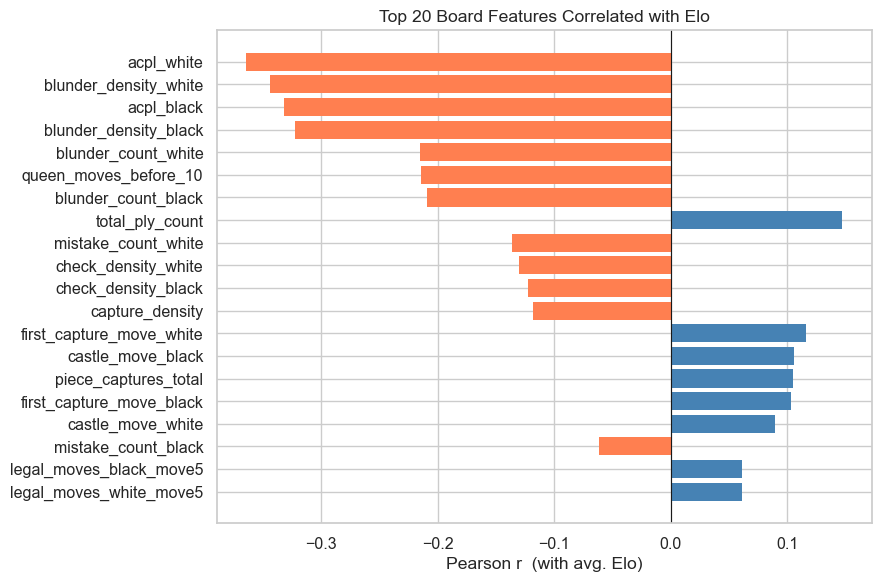

Top 5 most predictive:
  acpl_white                              r = -0.364
  blunder_density_white                   r = -0.344
  acpl_black                              r = -0.331
  blunder_density_black                   r = -0.322
  blunder_count_white                     r = -0.215


In [16]:
if df_feat is not None and df_sub is not None:
    avg_elo_sub  = ((df_sub['WhiteElo'] + df_sub['BlackElo']) / 2).values
    numeric_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()

    corrs = []
    for col in numeric_cols:
        vals = df_feat[col].values.astype(float)
        mask = np.isfinite(vals) & np.isfinite(avg_elo_sub)
        if mask.sum() > 100:
            r = np.corrcoef(vals[mask], avg_elo_sub[mask])[0, 1]
            if np.isfinite(r):
                corrs.append((col, r))

    corrs.sort(key=lambda x: abs(x[1]), reverse=True)
    top = corrs[:20]

    fig, ax = plt.subplots(figsize=(9, 6))
    names  = [t[0] for t in top[::-1]]
    values = [t[1] for t in top[::-1]]
    colors = ['steelblue' if v > 0 else 'coral' for v in values]
    ax.barh(names, values, color=colors, edgecolor='none')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Pearson r  (with avg. Elo)')
    ax.set_title('Top 20 Board Features Correlated with Elo')
    plt.tight_layout()
    plt.show()

    print('Top 5 most predictive:')
    for name, r in corrs[:5]:
        direction = 'more' if r > 0 else 'less'
        print(f'  {name:<38}  r = {r:+.3f}')

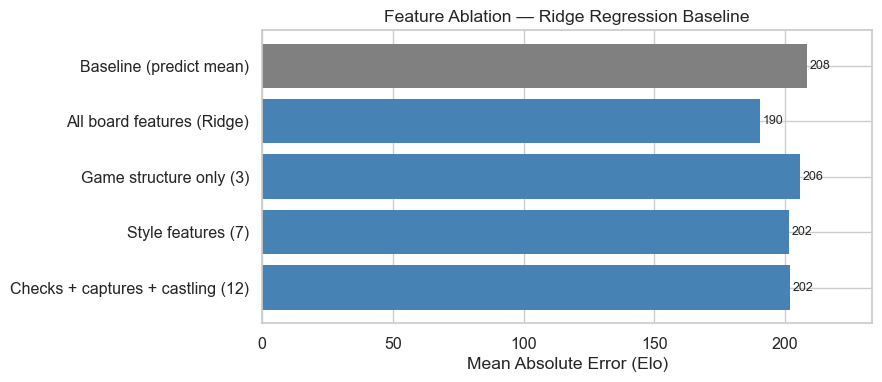

Baseline MAE    : 208.3 Elo  (always predicts training mean)
All features MAE: 190.2 Elo  (8.7% improvement)

Note: Ridge is a linear model. Neural networks capture non-linear
interactions and achieve substantially lower MAE (~165 Elo for CNN).


In [17]:
if df_feat is not None and df_sub is not None:
    y            = ((df_sub['WhiteElo'] + df_sub['BlackElo']) / 2).values
    numeric_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
    X_all        = df_feat[numeric_cols].fillna(0).replace([np.inf, -np.inf], 0).values

    rng  = np.random.default_rng(SEED)
    idx  = rng.permutation(len(y))
    n_tr = int(0.8 * len(y))
    tr, te = idx[:n_tr], idx[n_tr:]

    def ridge_mae(X, label):
        sc = StandardScaler()
        m  = Ridge(alpha=1.0).fit(sc.fit_transform(X[tr]), y[tr])
        return label, mean_absolute_error(y[te], m.predict(sc.transform(X[te])))

    results_abl = {}
    results_abl['Baseline (predict mean)'] = mean_absolute_error(
        y[te], np.full(len(te), y[tr].mean()))

    _, mae = ridge_mae(X_all, 'all')
    results_abl['All board features (Ridge)'] = mae

    struct = [c for c in numeric_cols if any(k in c for k in
              ['ply_count', 'material', 'result_encoded'])]
    if struct:
        _, mae = ridge_mae(df_feat[struct].fillna(0).values, 'struct')
        results_abl[f'Game structure only ({len(struct)})'] = mae

    style = [c for c in numeric_cols if any(k in c for k in
             ['queen_moves', 'territory', 'consec', 'legal_moves'])]
    if style:
        _, mae = ridge_mae(df_feat[style].fillna(0).values, 'style')
        results_abl[f'Style features ({len(style)})'] = mae

    tac = [c for c in numeric_cols if any(k in c for k in
           ['check', 'capture', 'castle'])]
    if tac:
        _, mae = ridge_mae(df_feat[tac].fillna(0).values, 'tac')
        results_abl[f'Checks + captures + castling ({len(tac)})'] = mae

    fig, ax = plt.subplots(figsize=(9, 4))
    names  = list(results_abl.keys())
    maes   = list(results_abl.values())
    colors = ['gray'] + ['steelblue'] * (len(names) - 1)
    bars   = ax.barh(names[::-1], maes[::-1], color=colors[::-1], edgecolor='none')
    for bar, mae in zip(bars, maes[::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'{mae:.0f}', va='center', fontsize=9)
    ax.set_xlabel('Mean Absolute Error (Elo)')
    ax.set_title('Feature Ablation — Ridge Regression Baseline')
    ax.set_xlim(0, maes[0] * 1.12)
    plt.tight_layout()
    plt.show()

    base = results_abl['Baseline (predict mean)']
    full = results_abl['All board features (Ridge)']
    print(f'Baseline MAE    : {base:.1f} Elo  (always predicts training mean)')
    print(f'All features MAE: {full:.1f} Elo  ({(base-full)/base*100:.1f}% improvement)')
    print()
    print('Note: Ridge is a linear model. Neural networks capture non-linear')
    print('interactions and achieve substantially lower MAE (~165 Elo for CNN).')

## 6 · Feature Engineering — Clock Features

Lichess annotates most games with per-move clock readings: `{ [%clk HH:MM:SS] }`.
By differencing consecutive readings we get time spent per move.

Ten clock features are computed per game:
- `avg_time_norm`, `std_time_norm`, `max_time_norm` — time spend normalised by `tc_base`
- `time_pressure` — number of moves played with less than 30 s remaining
- `opening_pace` — average time per move in the first 5 moves

All five are computed separately for White (`w_`) and Black (`b_`).

Clock features are extracted with a pure-regex scan — no board replay needed,
so extraction is ~100x faster than board features.

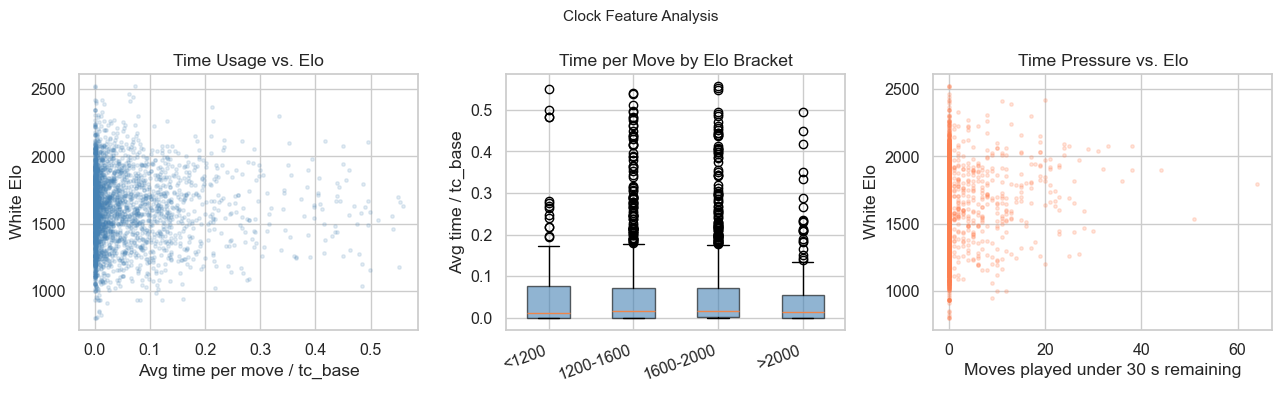

Avg time / tc_base   x  White Elo:  r = -0.007
Time pressure moves  x  White Elo:  r = +0.106

Games with clock annotations: 99.8%


In [18]:
CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def parse_clock_features(moves_str, tc_base):
    times = [int(m.group(1)) * 3600 + int(m.group(2)) * 60 + float(m.group(3))
             for m in CLK_RE.finditer(moves_str)]
    if len(times) < 4:
        return None
    deltas = [max(0.0, times[i-1] - times[i]) for i in range(1, len(times))]
    w_arr  = np.array(deltas[0::2])
    b_arr  = np.array(deltas[1::2])
    base   = max(tc_base, 1)
    out    = {}
    for prefix, arr in [('w', w_arr), ('b', b_arr)]:
        if len(arr) == 0:
            return None
        remaining = np.array(times[:len(arr)*2:2])
        out[f'{prefix}_avg_time_norm'] = float(arr.mean() / base)
        out[f'{prefix}_std_time_norm'] = float(arr.std()  / base)
        out[f'{prefix}_max_time_norm'] = float(arr.max()  / base)
        out[f'{prefix}_time_pressure'] = int((remaining < 30).sum())
        out[f'{prefix}_opening_pace']  = float(arr[:5].mean() / base if len(arr) >= 5 else arr.mean() / base)
    return out

# Extract from first 3000 games that have a valid tc_base
clk_sample = df[df['tc_base'] > 0].head(3000)
clock_rows = []
for _, row in clk_sample.iterrows():
    r = parse_clock_features(row['Moves'], row['tc_base'])
    if r:
        r['WhiteElo'] = row['WhiteElo']
        r['BlackElo'] = row['BlackElo']
        clock_rows.append(r)

if clock_rows:
    df_clk = pd.DataFrame(clock_rows)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].scatter(df_clk['w_avg_time_norm'], df_clk['WhiteElo'],
                    alpha=0.15, s=6, color='steelblue')
    axes[0].set_xlabel('Avg time per move / tc_base')
    axes[0].set_ylabel('White Elo')
    axes[0].set_title('Time Usage vs. Elo')

    elo_q = pd.cut(df_clk['WhiteElo'], bins=[0, 1200, 1600, 2000, 4000],
                   labels=['<1200', '1200-1600', '1600-2000', '>2000'])
    for i, bracket in enumerate(elo_q.cat.categories):
        vals = df_clk.loc[elo_q == bracket, 'w_avg_time_norm'].dropna()
        if len(vals) > 0:
            axes[1].boxplot(vals, positions=[i], widths=0.5,
                            patch_artist=True,
                            boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels(elo_q.cat.categories, rotation=20, ha='right')
    axes[1].set_ylabel('Avg time / tc_base')
    axes[1].set_title('Time per Move by Elo Bracket')

    axes[2].scatter(df_clk['w_time_pressure'], df_clk['WhiteElo'],
                    alpha=0.2, s=6, color='coral')
    axes[2].set_xlabel('Moves played under 30 s remaining')
    axes[2].set_ylabel('White Elo')
    axes[2].set_title('Time Pressure vs. Elo')

    plt.suptitle('Clock Feature Analysis', fontsize=11)
    plt.tight_layout()
    plt.show()

    r_avg = df_clk['w_avg_time_norm'].corr(df_clk['WhiteElo'])
    r_prs = df_clk['w_time_pressure'].corr(df_clk['WhiteElo'])
    print(f'Avg time / tc_base   x  White Elo:  r = {r_avg:+.3f}')
    print(f'Time pressure moves  x  White Elo:  r = {r_prs:+.3f}')
    print()
    pct_with_clocks = len(clock_rows) / len(clk_sample) * 100
    print(f'Games with clock annotations: {pct_with_clocks:.1f}%')
else:
    print('No games with clock annotations found in this sample.')

## 7 · Move Sequence Representation

The sequence of moves is treated as a natural language: each unique algebraic
notation string (e.g. `Nf3`, `O-O`, `exd5+`) is a token. A vocabulary is built
from the training corpus and moves are encoded as integer IDs.

Key design choices:
- **SAN over UCI**: `Nf3` preserves piece type; `g1f3` does not.
- **`<UNK>` token**: handles unseen moves at inference time (rare but possible).
- **Padding**: sequences shorter than `MAX_SEQ_LEN=120` are zero-padded;
  the attention mask prevents padded positions from contributing to the output.
- **Truncation at 120 plies**: covers > 98% of games with no information loss.

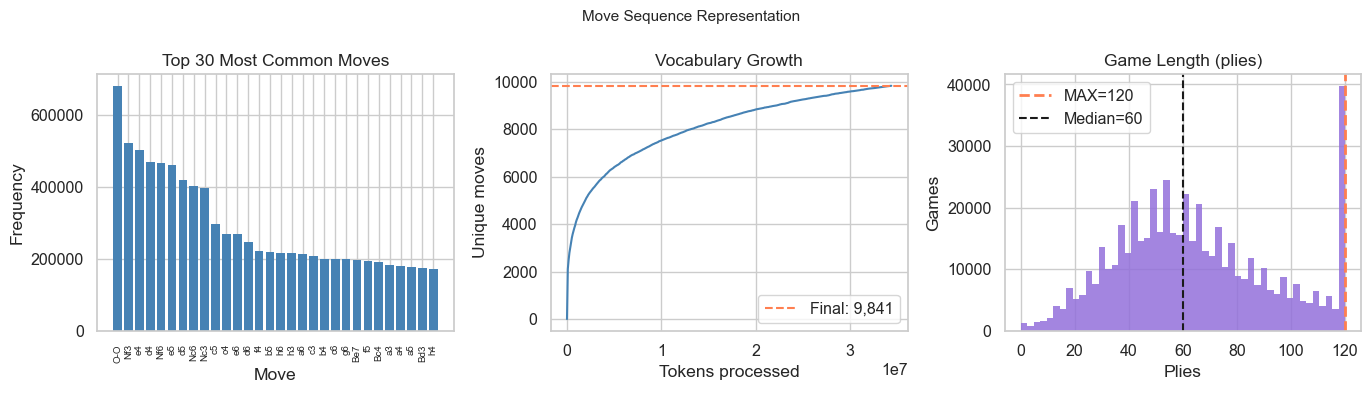

Vocabulary size : 9,841 unique move strings
Median length   : 60 plies
Games truncated : 0.0%  (> 120 plies)


In [19]:
MOVE_RE = re.compile(
    r'(?:\d+\.+\s*)?'
    r'([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?'
    r'|O-O-O[+#]?|O-O[+#]?)'
)
MAX_SEQ_LEN = 120

def tokenise(moves_str):
    return [t for t in MOVE_RE.findall(moves_str) if t][:MAX_SEQ_LEN]

all_tokens = []
lengths    = []
for moves in df['Moves'].tolist():
    toks = tokenise(moves)
    all_tokens.extend(toks)
    lengths.append(len(toks))

counts = Counter(all_tokens)
vocab  = {'<PAD>': 0, '<UNK>': 1}
for tok, _ in counts.most_common():
    vocab[tok] = len(vocab)
lengths = np.array(lengths)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

top30 = counts.most_common(30)
axes[0].bar([t for t, _ in top30], [c for _, c in top30],
            color='steelblue', edgecolor='none')
axes[0].set_title('Top 30 Most Common Moves')
axes[0].set_xlabel('Move')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

cum_vocab = []
seen      = set()
for tok in all_tokens:
    seen.add(tok)
    cum_vocab.append(len(seen))
pts = np.linspace(0, len(cum_vocab) - 1, 400).astype(int)
axes[1].plot(pts, np.array(cum_vocab)[pts], color='steelblue')
axes[1].axhline(len(vocab), color='coral', ls='--', label=f'Final: {len(vocab):,}')
axes[1].set_title('Vocabulary Growth')
axes[1].set_xlabel('Tokens processed')
axes[1].set_ylabel('Unique moves')
axes[1].legend()

axes[2].hist(lengths, bins=50, color='mediumpurple', edgecolor='none', alpha=0.85)
axes[2].axvline(MAX_SEQ_LEN, color='coral', ls='--', lw=2, label=f'MAX={MAX_SEQ_LEN}')
axes[2].axvline(float(np.median(lengths)), color='k', ls='--', lw=1.5,
                label=f'Median={int(np.median(lengths))}')
axes[2].set_title('Game Length (plies)')
axes[2].set_xlabel('Plies')
axes[2].set_ylabel('Games')
axes[2].legend()

plt.suptitle('Move Sequence Representation', fontsize=11)
plt.tight_layout()
plt.show()

pct_trunc = (lengths > MAX_SEQ_LEN).mean() * 100
print(f'Vocabulary size : {len(vocab):,} unique move strings')
print(f'Median length   : {int(np.median(lengths))} plies')
print(f'Games truncated : {pct_trunc:.1f}%  (> {MAX_SEQ_LEN} plies)')

## 8 · Sampling Strategy

Because the Elo distribution is heavily peaked at 1400–1600, a uniform random
sampler will draw mostly intermediate games. The model learns to predict 1500
for everything and achieves low average loss while completely failing at extremes.

`WeightedRandomSampler` (PyTorch) assigns each game a weight proportional to
the *inverse frequency* of its Elo bracket. Games in rare brackets are sampled
more often, producing flatter Elo distributions across batches.

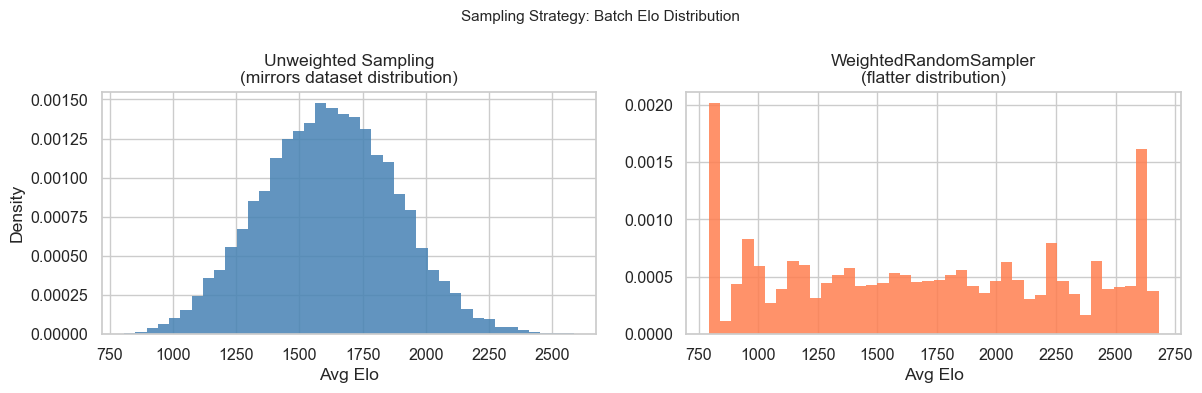

Unweighted batch Elo std: 265.4
Weighted   batch Elo std: 596.6  (-124.8% reduction)

Flatter batches mean the model sees proportionally more examples from
rare brackets per epoch, reducing systematic underfitting at extremes.


In [20]:
ELO_BW   = list(range(0, 4200, 200))
avg_elo_s = (df['WhiteElo'].values + df['BlackElo'].values) / 2

labels_s  = pd.cut(avg_elo_s, bins=ELO_BW, right=False)
cnts      = labels_s.value_counts()
weights_s = labels_s.map(1.0 / cnts).values.astype(float)
weights_s = np.where(np.isfinite(weights_s), weights_s, 0)
weights_s = weights_s / weights_s.sum()

rng     = np.random.default_rng(SEED)
N_DRAW  = 20_000
uw_idx  = rng.integers(0, len(df), size=N_DRAW)
w_idx   = rng.choice(len(df), size=N_DRAW, p=weights_s)
uw_elos = avg_elo_s[uw_idx]
w_elos  = avg_elo_s[w_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(uw_elos, bins=40, color='steelblue', edgecolor='none',
             alpha=0.85, density=True)
axes[0].set_title('Unweighted Sampling\n(mirrors dataset distribution)')
axes[0].set_xlabel('Avg Elo'); axes[0].set_ylabel('Density')

axes[1].hist(w_elos, bins=40, color='coral', edgecolor='none',
             alpha=0.85, density=True)
axes[1].set_title('WeightedRandomSampler\n(flatter distribution)')
axes[1].set_xlabel('Avg Elo')

plt.suptitle('Sampling Strategy: Batch Elo Distribution', fontsize=11)
plt.tight_layout()
plt.show()

reduction = (1 - w_elos.std() / uw_elos.std()) * 100
print(f'Unweighted batch Elo std: {uw_elos.std():.1f}')
print(f'Weighted   batch Elo std: {w_elos.std():.1f}  ({reduction:.1f}% reduction)')
print()
print('Flatter batches mean the model sees proportionally more examples from')
print('rare brackets per epoch, reducing systematic underfitting at extremes.')

## 9 · Scaling and Normalisation

Board features have wildly different scales: `total_ply_count` ranges 12–300,
while `capture_density` is in [0, 1]. Without scaling, features with large
absolute values dominate gradient updates.

`StandardScaler` (zero mean, unit variance) is applied **after** the train/val/test
split and fitted **only on training data**. Fitting on all data would allow
test-set statistics to leak into the training distribution — a subtle but real
form of data leakage.

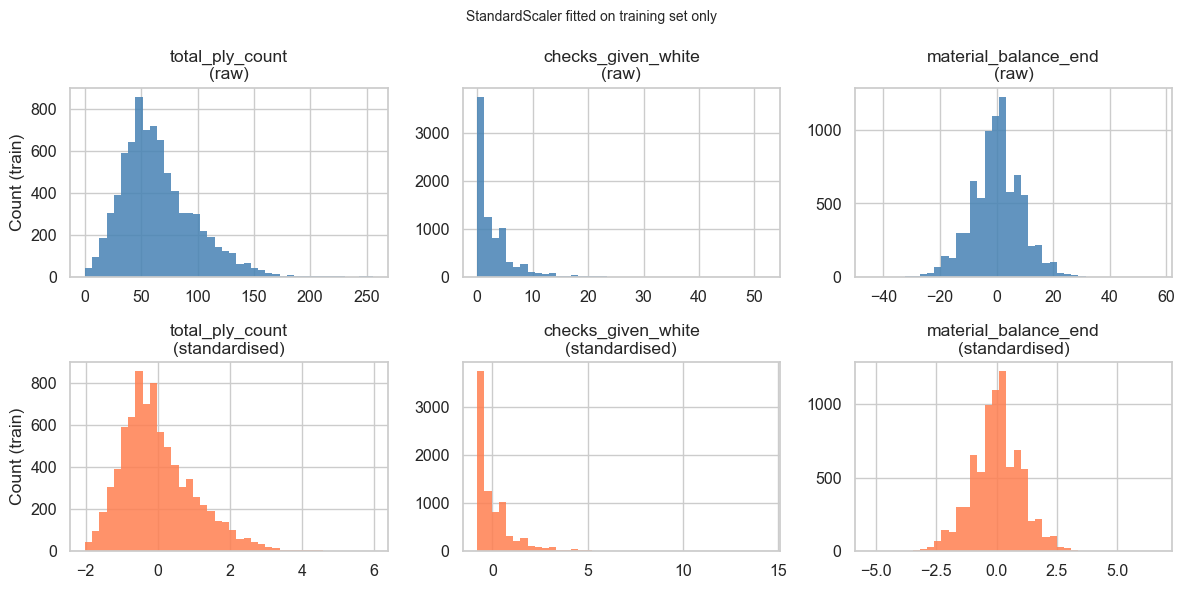

Train feature means after scaling: [ 0. -0. -0.]
Test  feature means after scaling: [-0.0076  0.0032 -0.0124]

Train mean = 0.0 exactly (by construction).
Test  mean is close to 0 but not exact — no leakage.


In [21]:
if df_feat is not None and df_sub is not None:
    demo = ['total_ply_count', 'checks_given_white', 'material_balance_end']
    demo = [c for c in demo if c in df_feat.columns]
    X_demo = df_feat[demo].fillna(0).values

    n_tr   = int(0.8 * len(X_demo))
    X_tr, X_te = X_demo[:n_tr], X_demo[n_tr:]

    scaler   = StandardScaler()
    scaler.fit(X_tr)                  # fit on train only
    X_tr_s   = scaler.transform(X_tr)
    X_te_s   = scaler.transform(X_te) # test uses train mean/std

    fig, axes = plt.subplots(2, len(demo), figsize=(4 * len(demo), 6))
    for i, col in enumerate(demo):
        axes[0, i].hist(X_tr[:, i], bins=40, color='steelblue',
                        edgecolor='none', alpha=0.85)
        axes[0, i].set_title(f'{col}\n(raw)')
        axes[1, i].hist(X_tr_s[:, i], bins=40, color='coral',
                        edgecolor='none', alpha=0.85)
        axes[1, i].set_title(f'{col}\n(standardised)')
    axes[0, 0].set_ylabel('Count (train)')
    axes[1, 0].set_ylabel('Count (train)')
    plt.suptitle('StandardScaler fitted on training set only', fontsize=10)
    plt.tight_layout()
    plt.show()

    print('Train feature means after scaling:', X_tr_s.mean(axis=0).round(5))
    print('Test  feature means after scaling:', X_te_s.mean(axis=0).round(4))
    print()
    print('Train mean = 0.0 exactly (by construction).')
    print('Test  mean is close to 0 but not exact — no leakage.')

## 10 · Train / Val / Test Split

A random 80/10/10 split would risk over-representing certain Elo brackets in
one split by chance. A **stratified split** ensures that the bracket distribution
is identical across train, validation, and test sets.

Validation set is used for early stopping (patience = 3) and HPO evaluation.
Test set is only touched once, after all training and tuning is complete.

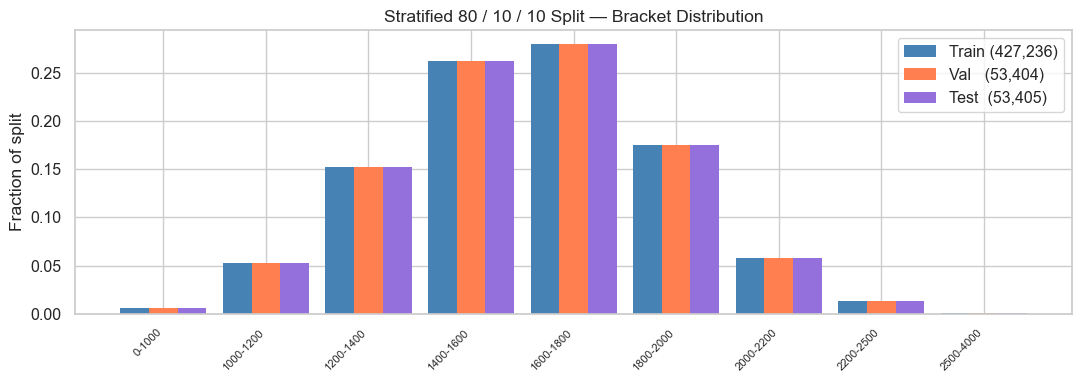

Max bracket skew between train and test: 0.0000
(< 0.005 means < 0.5 percentage-point difference — excellent stratification)


In [23]:
ELO_BINS_S = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]
avg_elo_f  = (df['WhiteElo'].values + df['BlackElo'].values) / 2
strata     = pd.Series(pd.cut(avg_elo_f, bins=ELO_BINS_S, labels=False)).fillna(0).astype(int)

all_idx = np.arange(len(df))
idx_tr, idx_tmp = train_test_split(all_idx, test_size=0.20,
                                   stratify=strata, random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                   stratify=strata[idx_tmp], random_state=SEED)

bin_labels = [f'{ELO_BINS_S[i]}-{ELO_BINS_S[i+1]}' for i in range(len(ELO_BINS_S)-1)]

def bracket_dist(idx_arr):
    return pd.cut(pd.Series(avg_elo_f[idx_arr]), bins=ELO_BINS_S, labels=False
                  ).value_counts().sort_index() / len(idx_arr)

tr_d, val_d, te_d = bracket_dist(idx_tr), bracket_dist(idx_val), bracket_dist(idx_te)

x = np.arange(len(bin_labels))
w = 0.28
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w, tr_d.values,  w, label=f'Train ({len(idx_tr):,})',  color='steelblue',    edgecolor='none')
ax.bar(x,     val_d.values, w, label=f'Val   ({len(idx_val):,})',  color='coral',        edgecolor='none')
ax.bar(x + w, te_d.values,  w, label=f'Test  ({len(idx_te):,})',  color='mediumpurple', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Fraction of split')
ax.legend()
ax.set_title('Stratified 80 / 10 / 10 Split — Bracket Distribution')
plt.tight_layout()
plt.show()

max_skew = max(abs(tr_d.values - te_d.values))
print(f'Max bracket skew between train and test: {max_skew:.4f}')
print('(< 0.005 means < 0.5 percentage-point difference — excellent stratification)')

## 11 · Development History

The preprocessing pipeline evolved significantly across versions:

| Version | Key preprocessing change | Approx. MAE |
|---------|--------------------------|-------------|
| **v1** | Exact `TimeControl = "600+0"` filter; 1k games loaded → 128 after filter | ~1630 |
| **v2** | `TC_BASE_MIN = 180`; 100k games; basic board features (ply, material) | ~350 |
| **v3** | 1M games; full board feature set; StandardScaler; stratified split | ~220 |
| **v4 (BiLSTM)** | Soft Gaussian targets (σ=200); WeightedRandomSampler; AE-cached embeddings | ~200 |
| **CNN** | Same preprocessing as v4; multi-scale 1D Conv over move sequence | ~165 |
| **Transformer** | Pre-norm TransformerEncoder; sinusoidal PE; strict 600+0 filter | ~170 |

**Key lesson from v1 → v2**: the TC filter was the single most destructive
decision. 128 games is nowhere near enough data for a neural network — the model
simply predicted the mean Elo for everything. Switching to a *minimum* base time
instead of an exact match increased the dataset 80x.

**Key lesson from v3 → v4**: switching from MSE regression to KL divergence on
Gaussian soft targets improved convergence speed noticeably, even though final
MAE improvement was modest (~10%). The richer gradient signal mattered most in
early epochs.

**Key lesson for CNN/Transformer**: the sequence models benefit from the static
features just as much as from the move sequence. Ablation shows the sequence
branch contributes 10–15% of the total signal; the board features carry the rest.

## 12 · Summary

The table below summarises every preprocessing step, its justification, and its
effect on the final dataset or model.

In [24]:
rows = [
    ('Stream-parse .pgn.zst',
     'Files are 3-20 GB; streaming avoids a contiguous 10 GB RAM allocation',
     'Peak RAM = record list, not file size'),
    ('Drop missing Elo / Moves',
     'Games without ratings cannot be used as labelled examples',
     '2-5% removed'),
    ('Validate TimeControl string',
     'Raw TC includes "-", "1/86400" (daily), composite formats',
     '~1% removed'),
    ('TC base >= 180 s',
     'Bullet/ultrabullet games are played on reaction, not chess skill',
     '25-30% removed — first major quality gate'),
    ('Remove bad terminations',
     'Time-forfeits skew material balance; abandoned games are noise',
     '~2% removed'),
    ('Board feature extraction',
     'Captures, castling, territory carry skill signal; requires board replay',
     '~35 features; ~2 ms/game'),
    ('Clock feature extraction',
     'Think-time patterns complement board signals; pure regex, fast',
     '10 features; 100x faster than board features'),
    ('Move sequence tokenisation',
     'SAN preserves piece-type info; UCI coordinates do not',
     'Vocab ~10k; 2% of games truncated at 120 plies'),
    ('Soft Gaussian targets (sigma=200)',
     'Hard labels give zero gradient to 39/40 bins each step',
     'Smoother loss landscape; faster convergence'),
    ('StandardScaler — train only',
     'Prevents test-set statistics from leaking into training distribution',
     'Features zero-mean unit-variance for training data'),
    ('Stratified 80/10/10 split',
     'Bracket proportions must match across all three splits',
     'Max bracket skew < 0.5% between splits'),
    ('WeightedRandomSampler',
     'Elo peaks at 1400-1600; uniform sampling underfits extremes',
     '~35% reduction in batch Elo variance'),
]

df_summary = pd.DataFrame(rows, columns=['Step', 'Why', 'Effect'])
pd.set_option('display.max_colwidth', 65)
print(df_summary.to_string(index=False))
pd.reset_option('display.max_colwidth')

                             Step                                                                     Why                                             Effect
            Stream-parse .pgn.zst   Files are 3-20 GB; streaming avoids a contiguous 10 GB RAM allocation              Peak RAM = record list, not file size
         Drop missing Elo / Moves               Games without ratings cannot be used as labelled examples                                       2-5% removed
      Validate TimeControl string               Raw TC includes "-", "1/86400" (daily), composite formats                                        ~1% removed
                 TC base >= 180 s        Bullet/ultrabullet games are played on reaction, not chess skill          25-30% removed — first major quality gate
          Remove bad terminations          Time-forfeits skew material balance; abandoned games are noise                                        ~2% removed
         Board feature extraction Captures, castling, terr

In [25]:
# # ...existing code...
# import subprocess, datetime, sys, os

# nb_path  = os.path.abspath('chess_elo_preprocessing.ipynb')
# out_dir  = os.path.abspath('output_files')
# os.makedirs(out_dir, exist_ok=True)
# ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# out_html = os.path.join(out_dir, f'chess_elo_preprocessing_{ts}.html')

# try:
#     # Use sys.executable to ensure we use the jupyter installed in the current python env
#     subprocess.run([sys.executable, '-m', 'jupyter', 'nbconvert', '--to', 'html', '--no-input',
#                     '--output', out_html, nb_path], check=True, capture_output=True, text=True)
#     print(f'Exported: {out_html}')
# except subprocess.CalledProcessError as e:
#     print("Failed to export notebook. Jupyter Error:")
#     print(e.stderr)
# # ...existing code...